### Validates the BR08 discrete variance decay algorithm for numerical mixing.
Analyze output of MPAS-O setup as a doubly-periodic channel. Initial zonal velocity only, all other debug flags configured such that the model behaves as a linear advection equation.

In [75]:
#Packages 
import numpy as np
import xarray as xr
import glob
import cmocean.cm as cmo
import matplotlib.cm as cmx
import matplotlib.pyplot as plt
import matplotlib.ticker as tick
import warnings
warnings.filterwarnings("ignore") #turns off annoying warnings
import matplotlib.colors as mcolors
from mpl_toolkits.axes_grid1.inset_locator import inset_axes
from matplotlib.ticker import FuncFormatter
import mosaic
from matplotlib.colors import SymLogNorm
from matplotlib.colors import LinearSegmentedColormap
from scipy.stats import binned_statistic

In [76]:
def center_vertices(dsg, hres):
    # Clean up the indexing so the domain is centered for plotting

    # Original vertices (x,y) arrays
    xv = dsg.xVertex.values
    yv = dsg.yVertex.values
    
    # Compute the new vertices based on your filtering and offset logic:
    
    # 1. Extract verticesOnCell (assuming shape: [nCells, maxVerticesPerCell])
    voc = dsg.verticesOnCell.values
    
    # 2. Build verts as in your snippet (shape: [nCells, maxVerticesPerCell, 2])
    verts = np.dstack((xv[voc - 1], yv[voc - 1]))
    nverts = np.sum(voc != 0, axis=1)
    verts_list = [vert[:n] for vert, n in zip(verts, nverts)]
    
    # 3. Filter verts using np.ptp
    idx = [np.ptp(vert[:, 0]) < 50000 for vert in verts_list]
    verts_filtered = np.array(verts_list)[idx]
    
    # 4. Copy and apply offsets
    nuverts = verts_filtered.copy()
    m_dsx = hres
    nuverts[:, :, 0] += m_dsx / 2
    nuverts[:, :, 1] -= m_dsx
    
    # Now, update dsg's xVertex and yVertex arrays accordingly:
    # But note: verts are grouped by cell, so we need to flatten and assign properly.
    
    # Because verts_filtered is a filtered subset of verts_list,
    # you should update only those cells where idx is True.
    
    # Get indices of cells that passed filter
    filtered_cells = np.where(idx)[0]
    
    # Create copies of xVertex and yVertex to modify
    new_xVertex = xv.copy()
    new_yVertex = yv.copy()
    
    # Loop over filtered cells and update the corresponding vertex coords
    for cell_i, verts_cell in zip(filtered_cells, nuverts):
        nv = verts_cell.shape[0]  # number of vertices for this cell
        vertex_inds = voc[cell_i, :nv] - 1  # zero-based vertex indices for this cell
        new_xVertex[vertex_inds] = verts_cell[:, 0]
        new_yVertex[vertex_inds] = verts_cell[:, 1]
    
    # Assign back to dsg (if dsg is an xarray Dataset or DataArray)
    dsg['xVertex'].values = new_xVertex
    dsg['yVertex'].values = new_yVertex

In [77]:
### Open output 
rootdir = '/pscratch/sd/d/dylan617/mnum_val/br08_validation/'

# Load datasets
dsi = xr.open_dataset(rootdir + 'channel_init.nc')
dso = xr.open_dataset(rootdir + 'output.nc')
dsd = xr.open_dataset(rootdir + 'analysis_members/discreteVarianceDecay.0001-01-01.nc')
center_vertices(dsi, 1.0) # Call fixing of vertices, second arg is horz res in meters

# dso.xtime

### Check that the initial velocity is equal to 1 in the zonal direction and zero in the meridional

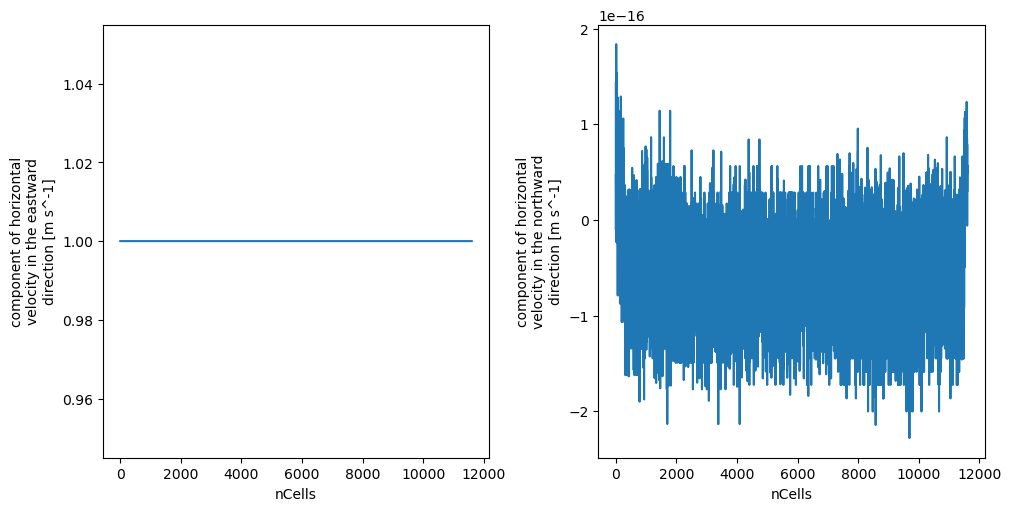

In [78]:
fig, ax = plt.subplots(1,2, constrained_layout=True, figsize=(10,5))
dso.velocityZonal[0].plot(ax=ax[0])
dso.velocityMeridional[0].plot(ax=ax[1])

### Now check the last timestep 

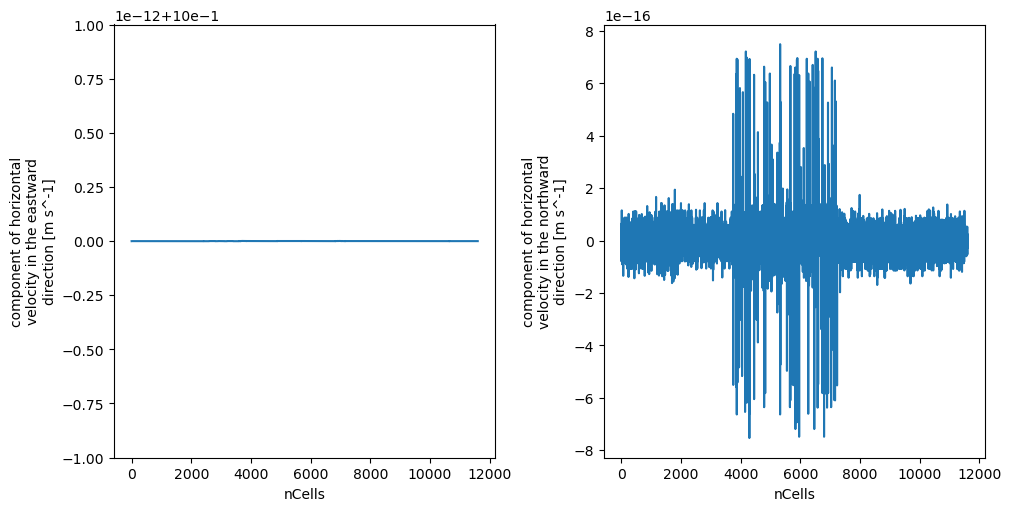

In [79]:
fig, ax = plt.subplots(1,2, constrained_layout=True, figsize=(10,5))
dso.velocityZonal[-1].plot(ax=ax[0])
dso.velocityMeridional[-1].plot(ax=ax[1])

### Plot a plan view at t = 0 and t = 100 sec

In [80]:
# Mosaic descriptor object, needed to plot the polygons
descriptor = mosaic.Descriptor(dsi,use_latlon=False)

# Used for plotting mnum on a diverging log colorbar
# Otherwise the extrema look the same for most cmocean maps. That is, 
# you can't tell dark reds or blues apart. 
def truncate_colormap(cmap, minval=0.0, maxval=0.8, n=256):
    """Truncates a colormap to use only part of the range."""
    new_cmap = LinearSegmentedColormap.from_list(
        f'trunc({cmap.name},{minval:.2f},{maxval:.2f})',
        cmap(np.linspace(minval, maxval, n))
    )
    return new_cmap

curl = truncate_colormap(plt.get_cmap('cmo.curl'), 0.1, 0.9)

# Helper to safely compute log10 for plotting, otherwise it is masked for 
# very small values
def safe_log10(data, floor=1e-10):
    """Compute log10 of xarray DataArray safely, keeping dimensions and attrs."""
    # Replace nonpositive or nonfinite values with floor
    data_clean = data.where((data > 0) & np.isfinite(data), other=floor)
    return np.log10(data_clean)

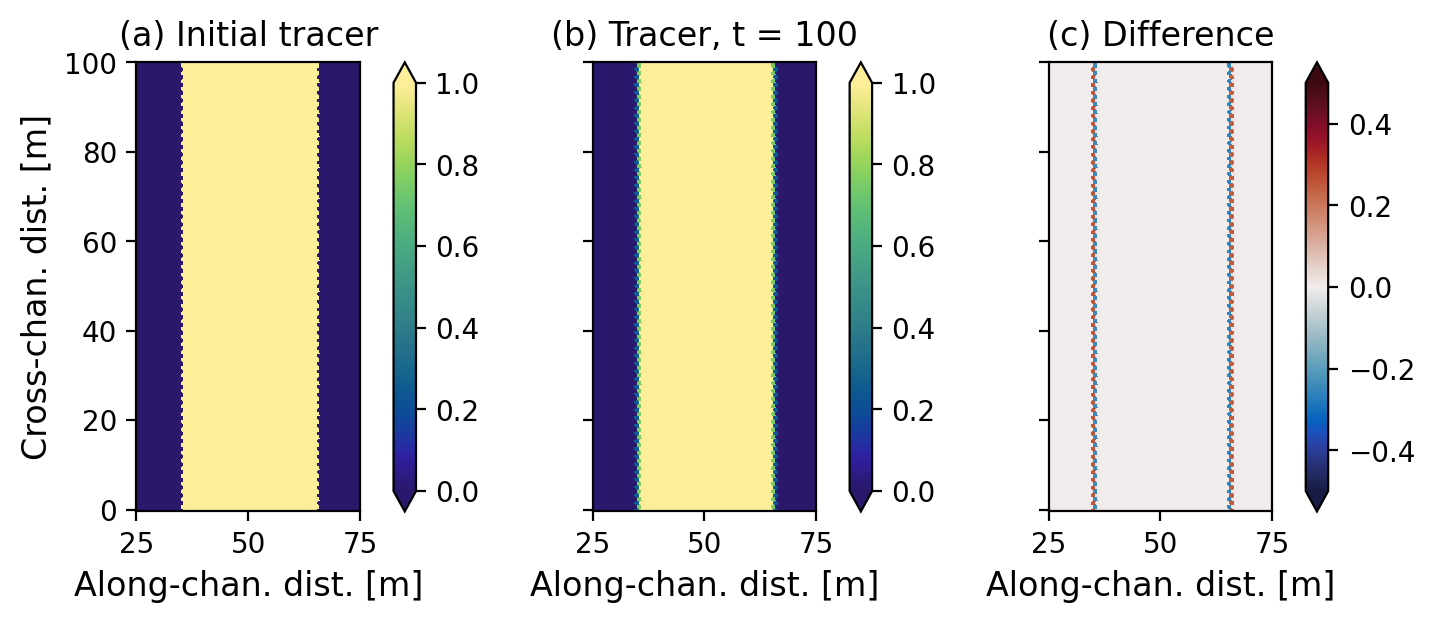

In [81]:
z = 0; t=-1
fig, axes = plt.subplots(1, 3, figsize=(7, 3), constrained_layout=True, dpi = 200)

# Panel (a): Salinity
c = mosaic.polypcolor(axes[0], descriptor,
                      dsi.salinity.isel(nVertLevels=z, Time=0),
                      cmap=cmo.haline, vmin=0, vmax=1,
                      antialiaseds=False)
fig.colorbar(c, ax=axes[0], extend='both')

# Panel (a): Salinity
c = mosaic.polypcolor(axes[1], descriptor,
                      dso.temperature.isel(nVertLevels=z, Time=t),
                      cmap=cmo.haline, vmin=0, vmax=1,
                      antialiaseds=False)
fig.colorbar(c, ax=axes[1], extend='both')

# # Panel (a): Salinity
c = mosaic.polypcolor(axes[2], descriptor,
                      dso.temperature.isel(nVertLevels=z, Time=t)-dso.salinity.isel(nVertLevels=z, Time=0),
                      cmap=cmo.balance, vmin=-.5, vmax=.5,
                      antialiaseds=False)

fig.colorbar(c, ax=axes[2], extend='both')


for ax in axes:
    # ax.set_xticks(np.arange(0, 350000, 50000))
    # ax.set_yticks(np.arange(0, 350000, 50000))
    ax.set_xlim(25,75)
    # ax.set_ylim(0, 101)
    ax.set_aspect(1.0)
    # ax.set_xticklabels([str(x) for x in ax.get_xticks()])
    # ax.set_yticklabels([str(y) for y in ax.get_yticks()])
    ax.set_xlabel('Along-chan. dist. [m]', fontsize=12)
    ax.set_ylabel('Cross-chan. dist. [m]', fontsize=12)

for ax in axes[1:]:
    ax.set_ylabel('')
    ax.set_yticklabels('')

axes[0].set_title('(a) Initial tracer')
axes[1].set_title('(b) Tracer, t = 100')
axes[2].set_title(r'(c) Difference')
plt.savefig('plan_view_channel.png',dpi=200, bbox_inches='tight')

### Meridional average 

In [82]:
# --- Load MPAS cell-centered data ---
xCell = dsi.xCell.values          # e.g., [0.5, 1.5, 2.5, ..., 100.0]
salt  = dso.salinity.isel(Time=-1, nVertLevels=0).values
dvd   = dsd.chiSpurSaltBR08.isel(Time=-1, nVertLevels=0).values

# --- Define bin edges so bins are centered at cell centers ---
dx = 1.0
x_bins = np.arange(0, L + dx, dx)     # edges: 0, 1, ..., 100
x_centers = np.arange(0.5, L + 0.5, dx)  # centers: 0.5, 1.5, ..., 100.5

# --- Compute meridional mean (in 1 m bins) ---
meridional_avg, _, _ = binned_statistic(xCell, salt, bins=x_bins, statistic='mean')
meridional_avg_dvd, _, _ = binned_statistic(xCell, dvd, bins=x_bins, statistic='mean')

# Aanlytical
def s_xt(x, t, u, L):
    shifted_x = (x - u * t) % L
    return s0(shifted_x)

# --- Parameters ---
L = 100       # domain length in meters
u = 1         # advection speed in m/s
t2 = 100     # time in seconds (e.g., after 100 seconds)

# --- Analytical solution at same centers ---
s_t1 = s_xt(x_centers, t2, u, L)


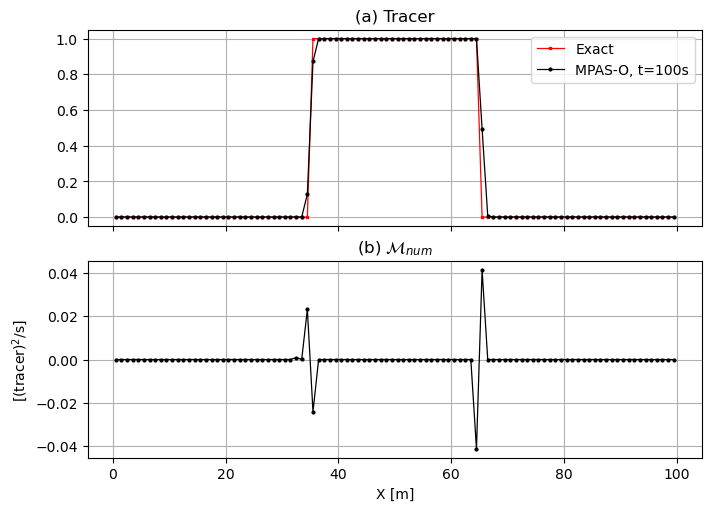

In [83]:
# --- Plot ---
fig, axs = plt.subplots(2, 1, figsize=(7, 5), sharex=True, constrained_layout=True)

axs[0].plot(x_centers, s_t1, label='Exact', marker='x', markersize=2, lw=0.9, c = 'r')
axs[0].plot(x_centers, meridional_avg, label='MPAS-O, t=100s',
             marker='o', markersize=2, lw=0.9, color='black')
axs[0].set_title('(a) Tracer')
axs[0].legend()
axs[0].grid()

axs[1].plot(x_centers, meridional_avg_dvd, marker='o', markersize=2, lw=0.9, color='black')
axs[1].set_xlabel('X [m]')
axs[1].set_ylabel(r'[(tracer)$^2$/s]')
axs[1].set_title(r'(b) $\mathcal{M}_{num}$')
axs[1].grid()

plt.savefig('1d_adv_mer_avg.png', dpi=300, bbox_inches='tight')
plt.show()

### Compute volume-integrated salinity variance budget

In [84]:
# --- Compute differential volume ---
dV = (dso.layerThickness * dsi.areaCell).astype(np.float64)

# --- Total volume ---
V = dV.sum(dim=['nVertLevels', 'nCells']).astype(np.float64)

# --- Mean salinity ---
sbar = ((dso.salinity * dV).sum(dim=['nVertLevels', 'nCells']) / V).astype(np.float64)

# --- Salinity variance ---
svar = ((dso.salinity - sbar)**2).astype(np.float64)

# --- Time step ---
dt = np.float64(0.5)

# --- Time tendency of salinity variance  ---
tend = (((svar.diff('Time') / dt) * dV.isel(Time=slice(1, None))))
tend = tend.sum(dim=['nVertLevels', 'nCells']).astype(np.float64)

# --- Numerical mixing diagnostic (also AB2) ---
# chiSpurSaltBR08 is the AB2-based estimate of mixing tendency
mnum_dv = ((dsd.chiSpurSaltBR08 * dsi.areaCell * dso.layerThickness)
           .sum(dim=['nVertLevels', 'nCells'])
           .astype(np.float64))

# --- Align mnum with tend, this was a pain to figure out ---
# The output is every DT, starting at t = 0, which is the initial condition. 
# Mnum isn't defined at t = 0, and AB2 timestepping introduces a 2-timestep lag.
# Doing a diff shifts time forward by 1. Here is a sketch
# -----------------------------------------------------------------
# Model timesteps (S[t]):
# t0       t1       t2       t3       t4       t5       t6       t7
# |Euler |AB2  |AB2  |AB2  |AB2  |AB2  |AB2  |AB2  |

# Raw numerical mixing (mnum_dv):
# t0       t1       t2       t3       t4       t5       t6       t7
# |-----|-----|-----|-----|-----|-----|-----|-----|

# Align for AB2 lag (shift forward by 2):
# mnum_aligned = -mnum_dv[2:len(tend)+2]
# t0       t1       t2       t3       t4       t5
#          |-----|-----|-----|-----|-----|-----|
#          mnum_aligned[0]  ← corresponds to tend[0]
#          mnum_aligned[1]  ← corresponds to tend[1]
#          ...

# Variance tendency (tend):
# t0       t1       t2       t3       t4       t5
# |-----|-----|-----|-----|-----|-----|
# tend[0] = uses S[0..2] (startup contaminated)
# tend[1] = uses S[1..3]
# tend[2] = uses S[2..4]
# tend[3] = uses S[3..5]
# tend[4] = uses S[4..6]

# Discard first 3 steps:
# tend_slice    = tend[3:]        ← tend[3], tend[4], ...
# mnum_slice    = mnum_aligned[3:] ← mnum_aligned[3], ...

# Effectively, the first 5 raw timesteps of S (t0..t4) are ignored:
# - t0: Euler startup
# - t1, t2: initial AB2 affected by startup
# - t3, t4: removed due to slice to align with tend_slice

# After this: tend_slice has len + 1 relative to mnum_slice.
# tend_slice[0]  ↔  mnum_slice[0]  (fully AB2-aligned)
# tend_slice[1]  ↔  mnum_slice[1]

# Also multiply by -1 to match the sign convention of variance tendency
mnum_aligned = -mnum_dv.isel(Time=slice(2, len(tend)+2))

# --- Throw out first 3 timesteps (optional) ---
# Early timesteps may be noisy due to initialization; this keeps arrays aligned
tend_slice = tend[3:]
mnum_slice = mnum_aligned[3:]

print(len(mnum_slice), len(tend_slice))

# --- Compute sums to verify agreement ---
total_tend = tend_slice[:-1].sum()
total_mnum = mnum_slice.sum()

print(f"Sum of tend after first 3 timesteps: {float(total_tend):.12e}")
print(f"Sum of numerical mixing after first 3 timesteps: {float(total_mnum):.12e}")

196 197
Sum of tend after first 3 timesteps: 2.623454784102e+01
Sum of numerical mixing after first 3 timesteps: 2.623454784102e+01


### Plot salinity variance budget 

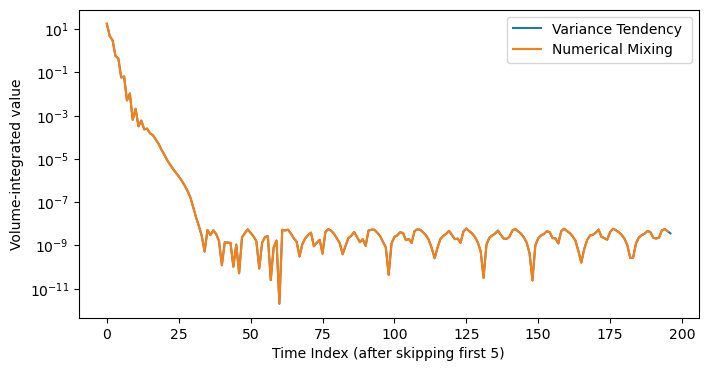

In [85]:
# --- Plotting ---
plt.figure(figsize=(8,4))
plt.plot(np.abs(tend_slice), label='Variance Tendency ')
plt.plot(np.abs(mnum_slice), label='Numerical Mixing ')
plt.xlabel('Time Index (after skipping first 5)')
plt.ylabel('Volume-integrated value')
plt.legend()
plt.semilogy()
plt.show()